# BWS Onboarding: Values Assessment

This notebook implements the **Best-Worst Scaling (BWS)** onboarding flow from
[`docs/onboarding/onboarding_spec.md`](../../docs/onboarding/onboarding_spec.md).

## What this produces

A **graded 10-dimensional weight vector** `w_u ∈ ℝ¹⁰` representing how much each
Schwartz value matters to this user. For example:

| Value | Benevolence | Self-Direction | Universalism | Security | ... |
|-------|:-----------:|:--------------:|:------------:|:--------:|-----|
| Weight | 0.19 | 0.17 | 0.13 | 0.11 | ... |

## How it links to the VIF

The `StateEncoder` in `src/vif/state_encoder.py` builds a state vector for every
journal entry:

```
state_vector = [text_embeddings (256d × window) | time_gaps | profile_weights (10d)]
```

The last 10 dimensions — `profile_weights` — are currently produced by
`parse_core_values_to_weights()`, which gives **equal weight to declared core values
and zero to everything else**. The BWS output replaces this with a **graded signal
across all 10 values**, which is more informative and psychometrically valid.

**The only change needed in `src/vif/` to use BWS weights:** swap the 10-dim profile
component in `StateEncoder._build_state_from_components()`. Everything else is
already compatible.

## How to use this notebook

1. Run **Section 2** to set up the item bank (no changes needed)
2. Run **Sections 3.1–3.3** (BWS sets 1–3), filling in your picks as variables
3. Run **Section 4** (mid-flow mirror) to see your preliminary profile
4. Run **Sections 3.4–3.6** (BWS sets 4–6), filling in your picks
5. Run **Section 5** (goal selection)
6. Run **Section 6** (scoring) — no interaction needed
7. Run **Section 7** to see your final profile and weight vector
8. Run **Section 8** to see the VIF integration


---
## Section 2 — Item Bank & Helpers


In [61]:
import json
import sys
from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

# Make src/ importable
repo_root = Path().resolve().parent.parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))


In [62]:
# ── Canonical value order (must match SCHWARTZ_VALUE_ORDER in src/models/judge.py) ──
SCHWARTZ_VALUE_ORDER = [
    'self_direction', 'stimulation', 'hedonism', 'achievement',
    'power', 'security', 'conformity', 'tradition',
    'benevolence', 'universalism',
]

# Display names (title-case) -> canonical snake_case key
VALUE_NAME_MAP = {
    'Self-Direction': 'self_direction',
    'Stimulation':    'stimulation',
    'Hedonism':       'hedonism',
    'Achievement':    'achievement',
    'Power':          'power',
    'Security':       'security',
    'Conformity':     'conformity',
    'Tradition':      'tradition',
    'Benevolence':    'benevolence',
    'Universalism':   'universalism',
}

# ── BWS card phrases (from spec §4, PVQ21-adapted) ──
CARD_PHRASES = {
    'Self-Direction': 'Having the freedom to choose my own path',
    'Stimulation':    'Seeking new experiences and challenges',
    'Hedonism':       'Enjoying life and having fun',
    'Achievement':    'Making progress toward something meaningful',
    'Power':          'Having influence over how things go',
    'Security':       'Feeling calm and secure in my life',
    'Conformity':     'Being someone others can count on to do the right thing',
    'Tradition':      'Honoring the customs and practices I was raised with',
    'Benevolence':    'Being there for the people closest to me',
    'Universalism':   'Making the world a fairer, better place',
}

# ── 6 BWS sets (Balanced Incomplete Block Design from spec §4) ──
# Each set mixes values from different higher-order quadrants.
BWS_SETS = [
    {'set': 1, 'items': ['Security', 'Self-Direction', 'Achievement', 'Benevolence'],
     'note': 'One value from each higher-order quadrant'},
    {'set': 2, 'items': ['Stimulation', 'Power', 'Conformity', 'Universalism'],
     'note': 'One value from each higher-order quadrant'},
    {'set': 3, 'items': ['Hedonism', 'Tradition', 'Self-Direction', 'Power'],
     'note': 'Cross-quadrant contrasts'},
    {'set': 4, 'items': ['Achievement', 'Benevolence', 'Stimulation', 'Conformity'],
     'note': 'Cross-quadrant contrasts'},
    {'set': 5, 'items': ['Security', 'Universalism', 'Hedonism', 'Tradition'],
     'note': 'Cross-quadrant contrasts'},
    {'set': 6, 'items': ['Self-Direction', 'Stimulation', 'Universalism', 'Security'],
     'note': 'Openness vs Conservation focus'},
]

# ── Goal categories (from spec §6) ──
GOAL_CATEGORIES = {
    'work_life_balance': 'I\'m stretched too thin between work and everything else',
    'life_transition':   'I\'m going through a career or life transition',
    'relationships':     'I want to be more present for people I care about',
    'health_wellbeing':  'I\'m neglecting my health or wellbeing',
    'direction':         'I feel stuck or unclear about my direction',
    'meaningful_work':   'I want to make more room for what matters to me',
}


def show_set(bws_set):
    """Print a BWS set with card phrases for reference."""
    s = bws_set['set']
    sep = '-' * 30
    print(f'Set {s} | {bws_set["note"]}')
    print('-' * 60)
    for i, value in enumerate(bws_set['items'], 1):
        phrase = CARD_PHRASES[value]
        print(f'  {i}. {value:<20}  "{phrase}"')
    items_str = ' / '.join(bws_set['items'])
    print(f'\nPick one MOST like you and one LEAST like you from: {items_str}')


print('Item bank loaded.')


Item bank loaded.


---
## Section 3 — BWS Responses

For each set, a display cell shows the cards, then a response cell has two variables
to fill in. Change the values to match your picks, then run the cell.

### 3.1 — Set 1


In [63]:
show_set(BWS_SETS[0])


Set 1 | One value from each higher-order quadrant
------------------------------------------------------------
  1. Security              "Feeling calm and secure in my life"
  2. Self-Direction        "Having the freedom to choose my own path"
  3. Achievement           "Making progress toward something meaningful"
  4. Benevolence           "Being there for the people closest to me"

Pick one MOST like you and one LEAST like you from: Security / Self-Direction / Achievement / Benevolence


In [64]:
# Valid values: 'Security', 'Self-Direction', 'Achievement', 'Benevolence'
set1_most  = 'Benevolence'    # <- change me
set1_least = 'Security'       # <- change me

assert set1_most  in BWS_SETS[0]['items'], f'{set1_most!r} not in Set 1'
assert set1_least in BWS_SETS[0]['items'], f'{set1_least!r} not in Set 1'
assert set1_most != set1_least, 'Most and Least must be different'
print(f'Set 1  Most: {set1_most:<20}  Least: {set1_least}')


Set 1  Most: Benevolence           Least: Security


### 3.2 — Set 2


In [65]:
show_set(BWS_SETS[1])


Set 2 | One value from each higher-order quadrant
------------------------------------------------------------
  1. Stimulation           "Seeking new experiences and challenges"
  2. Power                 "Having influence over how things go"
  3. Conformity            "Being someone others can count on to do the right thing"
  4. Universalism          "Making the world a fairer, better place"

Pick one MOST like you and one LEAST like you from: Stimulation / Power / Conformity / Universalism


In [66]:
# Valid values: 'Stimulation', 'Power', 'Conformity', 'Universalism'
set2_most  = 'Universalism'   # <- change me
set2_least = 'Power'          # <- change me

assert set2_most  in BWS_SETS[1]['items'], f'{set2_most!r} not in Set 2'
assert set2_least in BWS_SETS[1]['items'], f'{set2_least!r} not in Set 2'
assert set2_most != set2_least, 'Most and Least must be different'
print(f'Set 2  Most: {set2_most:<20}  Least: {set2_least}')


Set 2  Most: Universalism          Least: Power


### 3.3 — Set 3


In [67]:
show_set(BWS_SETS[2])


Set 3 | Cross-quadrant contrasts
------------------------------------------------------------
  1. Hedonism              "Enjoying life and having fun"
  2. Tradition             "Honoring the customs and practices I was raised with"
  3. Self-Direction        "Having the freedom to choose my own path"
  4. Power                 "Having influence over how things go"

Pick one MOST like you and one LEAST like you from: Hedonism / Tradition / Self-Direction / Power


In [68]:
# Valid values: 'Hedonism', 'Tradition', 'Self-Direction', 'Power'
set3_most  = 'Self-Direction' # <- change me
set3_least = 'Tradition'      # <- change me

assert set3_most  in BWS_SETS[2]['items'], f'{set3_most!r} not in Set 3'
assert set3_least in BWS_SETS[2]['items'], f'{set3_least!r} not in Set 3'
assert set3_most != set3_least, 'Most and Least must be different'
print(f'Set 3  Most: {set3_most:<20}  Least: {set3_least}')


Set 3  Most: Self-Direction        Least: Tradition


---
## Section 4 — Mid-flow Mirror

After the first 3 sets, the spec calls for a reflective mirror: compute a preliminary
profile and show it back to the user.


In [69]:
def compute_raw_scores(responses):
    """raw_score(v) = best_count(v) - worst_count(v) across all sets."""
    scores = {v: 0 for v in VALUE_NAME_MAP}
    for r in responses:
        scores[r['most']] += 1
        scores[r['least']] -= 1
    return scores


# Preliminary scores from sets 1-3
partial_responses = [
    {'set': 1, 'most': set1_most, 'least': set1_least},
    {'set': 2, 'most': set2_most, 'least': set2_least},
    {'set': 3, 'most': set3_most, 'least': set3_least},
]
partial_scores = compute_raw_scores(partial_responses)
sorted_partial = sorted(partial_scores.items(), key=lambda x: x[1], reverse=True)
top2    = [v for v, _ in sorted_partial[:2]]
bottom1 = sorted_partial[-1][0]

print('Here\'s what I\'m hearing so far...')
print('-' * 60)
print(f'It sounds like you care a lot about {top2[0]} and {top2[1]},')
print(f'and less about {bottom1}.')
print()
print('Does this feel roughly right?')
print('  -> If yes: continue to Set 4 below.')
print('  -> If not quite: set mirror_promote / mirror_demote in the next cell.')


Here's what I'm hearing so far...
------------------------------------------------------------
It sounds like you care a lot about Self-Direction and Benevolence,
and less about Tradition.

Does this feel roughly right?
  -> If yes: continue to Set 4 below.
  -> If not quite: set mirror_promote / mirror_demote in the next cell.


In [70]:
# ── Mid-flow refinement (optional) ──
# If the mirror didn't feel right, you can promote one value and demote another.
# Leave as None to accept the preliminary profile.
mirror_promote = None   # e.g. 'Security'       <- change me if needed
mirror_demote  = None   # e.g. 'Self-Direction'  <- change me if needed

if mirror_promote:
    assert mirror_promote in VALUE_NAME_MAP, f'{mirror_promote!r} not a valid value'
if mirror_demote:
    assert mirror_demote in VALUE_NAME_MAP, f'{mirror_demote!r} not a valid value'
    assert mirror_promote != mirror_demote, 'Promote and demote must be different'

if mirror_promote or mirror_demote:
    print(f'Mid-flow refinement recorded: promote={mirror_promote}, demote={mirror_demote}')
else:
    print('Mid-flow mirror accepted -- no adjustment.')


Mid-flow mirror accepted -- no adjustment.


---
## Section 3 (cont.) — Sets 4–6

### 3.4 — Set 4


In [71]:
show_set(BWS_SETS[3])


Set 4 | Cross-quadrant contrasts
------------------------------------------------------------
  1. Achievement           "Making progress toward something meaningful"
  2. Benevolence           "Being there for the people closest to me"
  3. Stimulation           "Seeking new experiences and challenges"
  4. Conformity            "Being someone others can count on to do the right thing"

Pick one MOST like you and one LEAST like you from: Achievement / Benevolence / Stimulation / Conformity


In [72]:
# Valid values: 'Achievement', 'Benevolence', 'Stimulation', 'Conformity'
set4_most  = 'Benevolence'    # <- change me
set4_least = 'Conformity'     # <- change me

assert set4_most  in BWS_SETS[3]['items'], f'{set4_most!r} not in Set 4'
assert set4_least in BWS_SETS[3]['items'], f'{set4_least!r} not in Set 4'
assert set4_most != set4_least, 'Most and Least must be different'
print(f'Set 4  Most: {set4_most:<20}  Least: {set4_least}')


Set 4  Most: Benevolence           Least: Conformity


### 3.5 — Set 5


In [73]:
show_set(BWS_SETS[4])


Set 5 | Cross-quadrant contrasts
------------------------------------------------------------
  1. Security              "Feeling calm and secure in my life"
  2. Universalism          "Making the world a fairer, better place"
  3. Hedonism              "Enjoying life and having fun"
  4. Tradition             "Honoring the customs and practices I was raised with"

Pick one MOST like you and one LEAST like you from: Security / Universalism / Hedonism / Tradition


In [74]:
# Valid values: 'Security', 'Universalism', 'Hedonism', 'Tradition'
set5_most  = 'Universalism'   # <- change me
set5_least = 'Tradition'      # <- change me

assert set5_most  in BWS_SETS[4]['items'], f'{set5_most!r} not in Set 5'
assert set5_least in BWS_SETS[4]['items'], f'{set5_least!r} not in Set 5'
assert set5_most != set5_least, 'Most and Least must be different'
print(f'Set 5  Most: {set5_most:<20}  Least: {set5_least}')


Set 5  Most: Universalism          Least: Tradition


### 3.6 — Set 6


In [75]:
show_set(BWS_SETS[5])


Set 6 | Openness vs Conservation focus
------------------------------------------------------------
  1. Self-Direction        "Having the freedom to choose my own path"
  2. Stimulation           "Seeking new experiences and challenges"
  3. Universalism          "Making the world a fairer, better place"
  4. Security              "Feeling calm and secure in my life"

Pick one MOST like you and one LEAST like you from: Self-Direction / Stimulation / Universalism / Security


In [76]:
# Valid values: 'Self-Direction', 'Stimulation', 'Universalism', 'Security'
set6_most  = 'Self-Direction' # <- change me
set6_least = 'Security'       # <- change me

assert set6_most  in BWS_SETS[5]['items'], f'{set6_most!r} not in Set 6'
assert set6_least in BWS_SETS[5]['items'], f'{set6_least!r} not in Set 6'
assert set6_most != set6_least, 'Most and Least must be different'
print(f'Set 6  Most: {set6_most:<20}  Least: {set6_least}')


Set 6  Most: Self-Direction        Least: Security


---
## Section 5 — Goal Selection


In [77]:
print('What brought you here?')
print('-' * 60)
for key, text in GOAL_CATEGORIES.items():
    print(f'  {key:<25}  "{text}"')


What brought you here?
------------------------------------------------------------
  work_life_balance          "I'm stretched too thin between work and everything else"
  life_transition            "I'm going through a career or life transition"
  relationships              "I want to be more present for people I care about"
  health_wellbeing           "I'm neglecting my health or wellbeing"
  direction                  "I feel stuck or unclear about my direction"
  meaningful_work            "I want to make more room for what matters to me"


In [78]:
goal_category = 'work_life_balance'   # <- change me

assert goal_category in GOAL_CATEGORIES, (
    f'{goal_category!r} not valid. Choose from: {list(GOAL_CATEGORIES)}'
)
print(f'Goal: "{GOAL_CATEGORIES[goal_category]}"')


Goal: "I'm stretched too thin between work and everything else"


---
## Section 6 — Scoring

Implements the scoring logic from spec §5.


In [79]:
def normalize_to_weights(raw_scores):
    """Shift scores to non-negative, then normalize to sum 1.

    From spec §5:
        shifted(v) = raw_score(v) - min(raw_scores) + 1
        w_u(v)     = shifted(v) / sum(shifted)

    The +1 ensures no value has zero weight.
    """
    min_score = min(raw_scores.values())
    shifted   = {v: s - min_score + 1 for v, s in raw_scores.items()}
    total     = sum(shifted.values())
    return {v: round(w / total, 4) for v, w in shifted.items()}


def compute_confidence(responses, raw_scores):
    """Estimate confidence in the BWS-derived profile.

    - consistent: no value appears as both Most and Least across sets
    - spread: std dev of raw scores (higher = more differentiated profile)
    - refinements: number of user corrections made
    """
    bests  = {r['most']  for r in responses}
    worsts = {r['least'] for r in responses}
    consistent = len(bests & worsts) == 0
    scores_array = np.array(list(raw_scores.values()), dtype=float)
    spread = round(float(np.std(scores_array)), 3)
    refinements = sum([
        mirror_promote is not None or mirror_demote is not None,
        end_promote is not None or end_demote is not None,
    ])
    return {'consistent': consistent, 'spread': spread, 'refinements': refinements}


def apply_refinement(raw_scores, promote, demote):
    """Apply a promote/demote correction to raw scores (spec §5)."""
    adjusted = dict(raw_scores)
    if promote:
        adjusted[promote] = adjusted.get(promote, 0) + 1
    if demote:
        adjusted[demote] = adjusted.get(demote, 0) - 1
    return adjusted


print('Scoring functions defined.')


Scoring functions defined.


In [80]:
# ── End-summary refinement (optional) ──
end_promote = None   # e.g. 'Achievement'  <- change me if needed
end_demote  = None   # e.g. 'Hedonism'     <- change me if needed

if end_promote:
    assert end_promote in VALUE_NAME_MAP, f'{end_promote!r} not a valid value'
if end_demote:
    assert end_demote in VALUE_NAME_MAP, f'{end_demote!r} not a valid value'
    assert end_promote != end_demote, 'Promote and demote must be different'

if end_promote or end_demote:
    print(f'End-summary refinement: promote={end_promote}, demote={end_demote}')
else:
    print('End-summary accepted -- no adjustment.')


End-summary accepted -- no adjustment.


In [81]:
# ── Assemble all 6 responses and compute final scores ──
all_responses = [
    {'set': 1, 'most': set1_most, 'least': set1_least},
    {'set': 2, 'most': set2_most, 'least': set2_least},
    {'set': 3, 'most': set3_most, 'least': set3_least},
    {'set': 4, 'most': set4_most, 'least': set4_least},
    {'set': 5, 'most': set5_most, 'least': set5_least},
    {'set': 6, 'most': set6_most, 'least': set6_least},
]

raw_scores = compute_raw_scores(all_responses)

# Apply refinements (mid-flow mirror + end summary)
adjusted_scores = apply_refinement(raw_scores, mirror_promote, mirror_demote)
adjusted_scores = apply_refinement(adjusted_scores, end_promote, end_demote)

weights    = normalize_to_weights(adjusted_scores)
confidence = compute_confidence(all_responses, adjusted_scores)
top_values = sorted(weights, key=weights.get, reverse=True)[:3]

print('Raw scores:')
for v, s in sorted(adjusted_scores.items(), key=lambda x: x[1], reverse=True):
    bar = '#' * max(0, s + 3)
    print(f'  {v:<20} {s:+d}  {bar}')


Raw scores:
  Self-Direction       +2  #####
  Benevolence          +2  #####
  Universalism         +2  #####
  Stimulation          +0  ###
  Hedonism             +0  ###
  Achievement          +0  ###
  Power                -1  ##
  Conformity           -1  ##
  Security             -2  #
  Tradition            -2  #


---
## Section 7 — Output: Your Value Profile


In [82]:
# ── Build the full output JSON (spec §7 schema) ──
refinements_log = []
if mirror_promote or mirror_demote:
    refinements_log.append({
        'stage': 'mid_flow',
        'promote': mirror_promote,
        'demote': mirror_demote,
    })
if end_promote or end_demote:
    refinements_log.append({
        'stage': 'end_summary',
        'promote': end_promote,
        'demote': end_demote,
    })

onboarding_output = {
    'user_id': 'demo',
    'onboarding_version': '1.0.0',
    'timestamp': datetime.utcnow().isoformat() + 'Z',
    'bws_responses': [
        {
            'set_number': r['set'],
            'items': BWS_SETS[r['set'] - 1]['items'],
            'selected_best': r['most'],
            'selected_worst': r['least'],
        }
        for r in all_responses
    ],
    'value_scores': {
        'raw':     {k: int(v) for k, v in adjusted_scores.items()},
        'weights': weights,
    },
    'confidence': confidence,
    'top_values': top_values,
    'goal_category': goal_category,
    'user_confirmed': True,
    'refinements': refinements_log,
    'mirror_responses': {
        'mid_flow':    {'accepted': mirror_promote is None and mirror_demote is None},
        'end_summary': {'accepted': end_promote is None and end_demote is None},
    },
}

print(json.dumps(onboarding_output, indent=2))


{
  "user_id": "demo",
  "onboarding_version": "1.0.0",
  "timestamp": "2026-02-26T11:46:26.021618Z",
  "bws_responses": [
    {
      "set_number": 1,
      "items": [
        "Security",
        "Self-Direction",
        "Achievement",
        "Benevolence"
      ],
      "selected_best": "Benevolence",
      "selected_worst": "Security"
    },
    {
      "set_number": 2,
      "items": [
        "Stimulation",
        "Power",
        "Conformity",
        "Universalism"
      ],
      "selected_best": "Universalism",
      "selected_worst": "Power"
    },
    {
      "set_number": 3,
      "items": [
        "Hedonism",
        "Tradition",
        "Self-Direction",
        "Power"
      ],
      "selected_best": "Self-Direction",
      "selected_worst": "Tradition"
    },
    {
      "set_number": 4,
      "items": [
        "Achievement",
        "Benevolence",
        "Stimulation",
        "Conformity"
      ],
      "selected_best": "Benevolence",
      "selected_worst": "Con

/var/folders/0_/3pl6888s5j13pjsxp4wzz1s00000gp/T/ipykernel_80764/973212205.py:19: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  'timestamp': datetime.utcnow().isoformat() + 'Z',


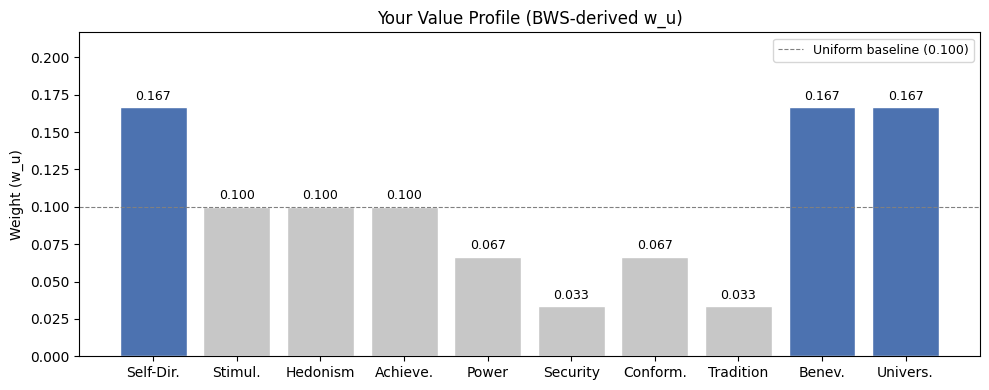

Top 3 values: Self-Direction, Benevolence, Universalism
Confidence:   spread=1.48  consistent=True  refinements=0
Goal:         "I'm stretched too thin between work and everything else"


In [83]:
# ── Visualise the weight vector ──
display_names = [
    'Self-Dir.', 'Stimul.', 'Hedonism', 'Achieve.',
    'Power', 'Security', 'Conform.', 'Tradition',
    'Benev.', 'Univers.',
]
inv_map = {v: k for k, v in VALUE_NAME_MAP.items()}
ordered_keys    = [inv_map[k] for k in SCHWARTZ_VALUE_ORDER]
ordered_weights = [weights[k] for k in ordered_keys]
threshold       = sorted(ordered_weights)[-3]
colors          = ['#4C72B0' if w >= threshold else '#C7C7C7'
                   for w in ordered_weights]

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(display_names, ordered_weights, color=colors, edgecolor='white')
ax.set_ylabel('Weight (w_u)')
ax.set_title('Your Value Profile (BWS-derived w_u)')
ax.set_ylim(0, max(ordered_weights) * 1.3)
for bar, w in zip(bars, ordered_weights):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.003,
            f'{w:.3f}', ha='center', va='bottom', fontsize=9)
ax.axhline(1 / len(SCHWARTZ_VALUE_ORDER), color='gray', linestyle='--',
           linewidth=0.8, label='Uniform baseline (0.100)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print(f'Top 3 values: {", ".join(top_values)}')
print(f'Confidence:   spread={confidence["spread"]:.2f}  '
      f'consistent={confidence["consistent"]}  '
      f'refinements={confidence["refinements"]}')
print(f'Goal:         "{GOAL_CATEGORIES[goal_category]}"')


---
## Section 8 — VIF Integration: How w_u Feeds Into the Critic

The `StateEncoder` in `src/vif/state_encoder.py` builds a state vector for every
journal entry by concatenating three components:

```
state_vector = [
    text_embeddings   # 256d x window_size — what was written
    time_gaps         # (window_size - 1) — how far apart entries were
    profile_weights   # 10d  <-- THIS is where BWS feeds in
]
```

The Critic receives this full state vector and predicts alignment scores for all
10 dimensions simultaneously. The profile weights tell the Critic *which dimensions
matter more* for this user.

### Current approach vs. BWS


<All keys matched successfully>


Encoder:       nomic-ai/nomic-embed-text-v1.5
Embedding dim: 256
State dim:     780


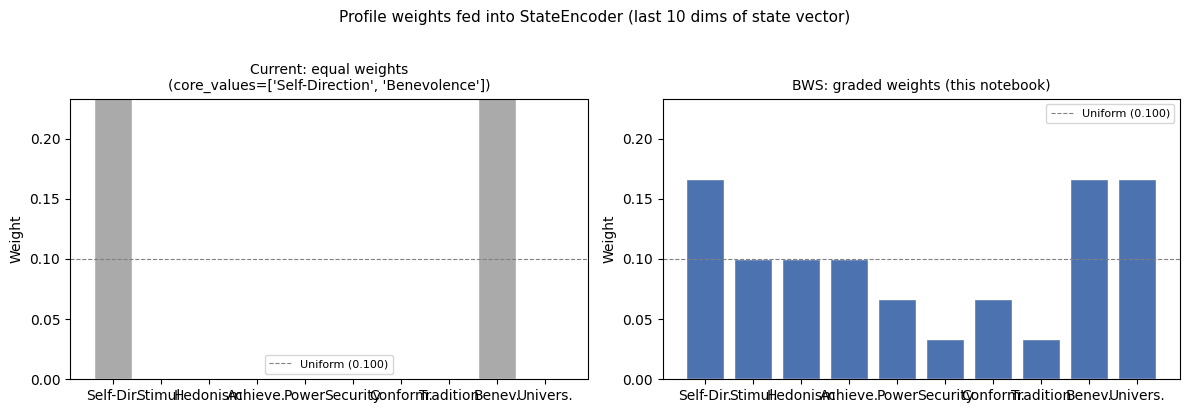

Binary weights (current):
  [0.5 0.  0.  0.  0.  0.  0.  0.  0.5 0. ]
BWS weights (graded):
  [0.167 0.1   0.1   0.1   0.067 0.033 0.067 0.033 0.167 0.167]
Both sum to 1.0: binary=1.000, BWS=1.000


In [84]:
from src.vif.encoders import SBERTEncoder
from src.vif.state_encoder import StateEncoder

text_encoder = SBERTEncoder(
    "nomic-ai/nomic-embed-text-v1.5",
    trust_remote_code=True,
    truncate_dim=256,        # Matryoshka truncation (MTEB 61.04 @ 256d)
    text_prefix="classification: ",
)
state_encoder = StateEncoder(text_encoder)

print(f"Encoder:       {text_encoder.model_name}")
print(f"Embedding dim: {text_encoder.embedding_dim}")
print(f"State dim:     {state_encoder.state_dim}")

# Current approach: parse_core_values_to_weights
# Equal weight to declared core values; everything else is 0.
simulated_core_values = top_values[:2]
binary_weights = state_encoder.parse_core_values_to_weights(simulated_core_values)

# BWS approach: graded weights from this notebook
bws_weights_array = np.array(
    [weights[inv_map[k]] for k in SCHWARTZ_VALUE_ORDER],
    dtype='float32',
)

# Side-by-side comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=False)

for ax, w_array, title, color in zip(
    axes,
    [binary_weights, bws_weights_array],
    [f'Current: equal weights\n(core_values={simulated_core_values})',
     'BWS: graded weights (this notebook)'],
    ['#AAAAAA', '#4C72B0'],
):
    ax.bar(display_names, w_array, color=color, edgecolor='white')
    ax.set_title(title, fontsize=10)
    ax.set_ylabel('Weight')
    ax.set_ylim(0, max(bws_weights_array) * 1.4)
    ax.axhline(1 / len(SCHWARTZ_VALUE_ORDER), color='gray',
               linestyle='--', linewidth=0.8, label='Uniform (0.100)')
    ax.legend(fontsize=8)

plt.suptitle('Profile weights fed into StateEncoder (last 10 dims of state vector)',
             fontsize=11, y=1.02)
plt.tight_layout()
plt.show()

print('Binary weights (current):')
print(' ', binary_weights.round(3))
print('BWS weights (graded):')
print(' ', bws_weights_array.round(3))
print(f'Both sum to 1.0: binary={binary_weights.sum():.3f}, BWS={bws_weights_array.sum():.3f}')


### The single integration point

In `src/vif/state_encoder.py`, the profile weights are produced at line 287:

```python
# Current (StateEncoder._build_state_from_components, line 287)
profile_weights = self.parse_core_values_to_weights(core_values)
```

To use BWS weights instead, this becomes:

```python
# With BWS onboarding output
profile_weights = np.array(
    [bws_output['value_scores']['weights'][display_name]
     for display_name in [inv_map[k] for k in SCHWARTZ_VALUE_ORDER]],
    dtype='float32',
)
```

**Nothing else in the pipeline needs to change.** The MLP Critic already expects a
10-dim float vector — it doesn't know or care whether those floats came from binary
core-value parsing or from a BWS score.

### The full data flow

```
User completes BWS onboarding
         |
         v
  onboarding_output['value_scores']['weights']   <- this notebook's output
         |
         v
  StateEncoder._build_state_from_components()
         |  profile_weights = bws_weights (10d)
         v
  state_vector = [text_emb | time_gaps | profile_weights]
         |
         v
  VIF Critic -> alignment scores for all 10 dimensions
         |
         v
  Drift detection (Sudden Crash / Chronic Rut)
```


---
## Section 9 — Pydantic Output Model

`OnboardingOutput` validates and normalises the notebook's raw output into a
typed, canonical form ready to pass to downstream components (StateEncoder,
registry).

**Guarantees:**
- `weights` — 10-element list ordered per `SCHWARTZ_VALUE_ORDER`, summing to 1.0 ± 1e-4.
  Accepts either a title-case dict (e.g. `"Self-Direction"`) or a snake_case dict
  (e.g. `"self_direction"`) and maps to the canonical order automatically.
- `top_values` — stored as canonical **snake_case** strings regardless of input case.
- `goal_category` — must be one of the six valid categories from spec §6.
- `confidence` — bundles `consistent`, `spread`, and `refinements`.

In [85]:
from pydantic import BaseModel, Field, field_validator, model_validator
from typing import Any

# ── Reuse constants already loaded in Section 2 ──
_CANONICAL_ORDER = SCHWARTZ_VALUE_ORDER   # 10-element snake_case list
_TITLE_TO_SNAKE  = VALUE_NAME_MAP         # title-case → snake_case
_VALID_GOALS     = frozenset(GOAL_CATEGORIES)


def _norm_value_name(name: str) -> "str | None":
    """Normalize title-case or snake_case value name → canonical snake_case."""
    if name in _TITLE_TO_SNAKE:
        return _TITLE_TO_SNAKE[name]
    if name in _CANONICAL_ORDER:
        return name
    candidate = name.lower().replace('-', '_').strip()
    return candidate if candidate in _CANONICAL_ORDER else None


class OnboardingConfidence(BaseModel):
    consistent:   bool
    spread:       float = Field(ge=0.0)
    refinements:  int   = Field(ge=0)


class OnboardingOutput(BaseModel):
    """Validated BWS onboarding result.

    ``weights`` is stored as a 10-element list ordered per SCHWARTZ_VALUE_ORDER.
    Both title-case dict keys (e.g. 'Self-Direction') and snake_case keys
    (e.g. 'self_direction') are accepted and mapped automatically.
    ``top_values`` are normalized to canonical snake_case.
    """
    weights:       list[float]
    top_values:    list[str]
    goal_category: str
    confidence:    OnboardingConfidence

    @model_validator(mode='before')
    @classmethod
    def _coerce_weights_dict(cls, data: Any) -> Any:
        """Convert weights dict (any case) to ordered list before validation."""
        if not isinstance(data, dict):
            return data
        raw = data.get('weights')
        if not isinstance(raw, dict):
            return data
        ordered = []
        for snake in _CANONICAL_ORDER:
            val = raw.get(snake)
            if val is None:
                for title, s in _TITLE_TO_SNAKE.items():
                    if s == snake and title in raw:
                        val = raw[title]
                        break
            ordered.append(float(val) if val is not None else 0.0)
        return {**data, 'weights': ordered}

    @field_validator('weights')
    @classmethod
    def _check_weights(cls, v: list[float]) -> list[float]:
        if len(v) != 10:
            raise ValueError(f'weights must have 10 elements, got {len(v)}')
        if any(w < 0 for w in v):
            raise ValueError('all weights must be non-negative')
        total = sum(v)
        if abs(total - 1.0) > 1e-4:
            raise ValueError(f'weights must sum to 1.0, got {total:.6f}')
        return v

    @field_validator('top_values', mode='before')
    @classmethod
    def _normalize_top_values(cls, v: list[str]) -> list[str]:
        """Accept title-case or snake_case; return canonical snake_case."""
        out = []
        for name in v:
            key = _norm_value_name(name)
            if key is None:
                raise ValueError(f'Unknown value name {name!r}')
            out.append(key)
        return out

    @field_validator('goal_category')
    @classmethod
    def _check_goal(cls, v: str) -> str:
        if v not in _VALID_GOALS:
            raise ValueError(f'{v!r} not in {sorted(_VALID_GOALS)}')
        return v

    def to_weight_array(self) -> np.ndarray:
        """Return float32 ndarray aligned with SCHWARTZ_VALUE_ORDER."""
        return np.array(self.weights, dtype='float32')


print('OnboardingOutput model defined.')

OnboardingOutput model defined.


In [86]:
# ── Validate the onboarding_output dict produced in Section 7 ──
validated = OnboardingOutput(
    weights=onboarding_output['value_scores']['weights'],
    top_values=onboarding_output['top_values'],
    goal_category=onboarding_output['goal_category'],
    confidence=onboarding_output['confidence'],
)

bws_weights_array = validated.to_weight_array()

print('Validated OnboardingOutput:')
print(f'  weights (ordered list): {[round(w, 4) for w in validated.weights]}')
print(f'  top_values (snake_case): {validated.top_values}')
print(f'  goal_category: {validated.goal_category}')
print(f'  confidence.spread: {validated.confidence.spread}')
print()
print(f'  to_weight_array(): {bws_weights_array}')
print(f'  sum={bws_weights_array.sum():.4f}  dtype={bws_weights_array.dtype}')

Validated OnboardingOutput:
  weights (ordered list): [0.1667, 0.1, 0.1, 0.1, 0.0667, 0.0333, 0.0667, 0.0333, 0.1667, 0.1667]
  top_values (snake_case): ['self_direction', 'benevolence', 'universalism']
  goal_category: work_life_balance
  confidence.spread: 1.483

  to_weight_array(): [0.1667 0.1    0.1    0.1    0.0667 0.0333 0.0667 0.0333 0.1667 0.1667]
  sum=1.0001  dtype=float32


---
## Section 10 — StateEncoder: Graded Weight Integration

`StateEncoder._build_state_from_components` currently derives a binary profile
vector via `parse_core_values_to_weights`.  The wrapper below lets any caller
inject a pre-computed graded weight array (e.g. from BWS onboarding) **without
touching `src/vif/`**; it falls back deterministically to the existing
equal-weight behaviour when `profile_weights=None`.

In [87]:
def build_state_with_profile(
    state_enc,
    texts: list,
    dates: list,
    core_values: list,
    profile_weights: "np.ndarray | None" = None,
) -> np.ndarray:
    """Build a state vector, optionally substituting graded BWS weights.

    Args:
        state_enc:       StateEncoder instance.
        texts:           Entry texts, current first.
        dates:           Entry dates (YYYY-MM-DD), current first.
        core_values:     Declared core values — used only when profile_weights
                         is None (deterministic equal-weight fallback).
        profile_weights: Optional 10-dim float32 array from BWS onboarding.
                         When supplied it replaces the equal-weight profile.
    Returns:
        np.ndarray of shape (state_enc.state_dim,).
    """
    if profile_weights is not None:
        pw = np.asarray(profile_weights, dtype='float32')
        assert pw.shape == (10,), f'Expected shape (10,), got {pw.shape}'
        # Tolerance of 2e-3 accommodates float32 precision loss from 4-d.p.
        # rounded weights; the OnboardingOutput model already enforces ≤1e-4
        # at Python float precision before the array is cast.
        assert abs(pw.sum() - 1.0) < 2e-3, \
            f'Weights must sum to 1.0 (got {pw.sum():.6f})'
        _orig = state_enc.parse_core_values_to_weights
        state_enc.parse_core_values_to_weights = lambda _cv: pw
        try:
            return state_enc.build_state_vector(texts, dates, core_values)
        finally:
            state_enc.parse_core_values_to_weights = _orig
    return state_enc.build_state_vector(texts, dates, core_values)


print('build_state_with_profile defined.')


build_state_with_profile defined.


In [88]:
# ── Demo: equal-weight fallback vs graded BWS weights ──
# state_encoder is already initialised in Section 8 with the nomic encoder.
_texts = ['Sample journal entry about my day.']
_dates = ['2026-01-15']
_cvs   = [inv_map[k] for k in validated.top_values[:2]]  # title-case for encoder

state_equal  = build_state_with_profile(state_encoder, _texts, _dates, _cvs)
state_graded = build_state_with_profile(state_encoder, _texts, _dates, _cvs,
                                        profile_weights=bws_weights_array)

profile_equal  = state_equal[-10:]
profile_graded = state_graded[-10:]

print('Last 10 dims of state vector (profile component):')
print(f'  equal-weight : {profile_equal.round(3)}')
print(f'  BWS graded   : {profile_graded.round(3)}')
print(f'  Profiles differ: {not np.allclose(profile_equal, profile_graded)}')
print(f'  Both sum to 1.0: equal={profile_equal.sum():.3f}  graded={profile_graded.sum():.3f}')


Last 10 dims of state vector (profile component):
  equal-weight : [0.5 0.  0.  0.  0.  0.  0.  0.  0.5 0. ]
  BWS graded   : [0.167 0.1   0.1   0.1   0.067 0.033 0.067 0.033 0.167 0.167]
  Profiles differ: True
  Both sum to 1.0: equal=1.000  graded=1.000


---
## Section 11 — Registry Schema Extension

When a user completes onboarding, their BWS result can be stored alongside the
persona record.  The helpers below add onboarding columns to a registry
DataFrame and write a validated `OnboardingOutput` into a specific row.

Existing personas (the 180 synthetic personas already in
`logs/registry/personas.parquet`) are grandfathered: `add_onboarding_columns`
adds the new fields with `null` values, so they remain readable without any
data migration.

In [89]:
import polars as pl

# New columns + their Polars dtypes
ONBOARDING_REGISTRY_FIELDS: dict[str, pl.PolarsDataType] = {
    'onboarding_weights':            pl.List(pl.Float32),
    'onboarding_top_values':         pl.List(pl.Utf8),
    'onboarding_goal_category':      pl.Utf8,
    'onboarding_confidence_spread':  pl.Float32,
}


def add_onboarding_columns(df: pl.DataFrame) -> pl.DataFrame:
    """Add onboarding columns with null defaults (idempotent).

    Existing synthetic personas are grandfathered: missing columns are added
    as null.  Safe to call on a registry that already has the columns.
    """
    for col, dtype in ONBOARDING_REGISTRY_FIELDS.items():
        if col not in df.columns:
            df = df.with_columns(pl.lit(None).cast(dtype).alias(col))
    return df


def set_onboarding_fields(
    df: pl.DataFrame,
    persona_id: str,
    result: OnboardingOutput,
) -> pl.DataFrame:
    """Write BWS onboarding results into the registry row for persona_id."""
    updates = {
        'onboarding_weights':           result.weights,
        'onboarding_top_values':        result.top_values,
        'onboarding_goal_category':     result.goal_category,
        'onboarding_confidence_spread': result.confidence.spread,
    }
    for col, val in updates.items():
        df = df.with_columns(
            pl.when(pl.col('persona_id') == persona_id)
            .then(pl.lit(val))
            .otherwise(pl.col(col))
            .alias(col)
        )
    return df


# ── Demo: real registry ──
# repo_root is defined in the imports cell (Section 2).
_registry = pl.read_parquet(repo_root / 'logs/registry/personas.parquet')
_registry = add_onboarding_columns(_registry)

# Pick two real labeled personas: one receives onboarding data, one stays null.
_labeled   = _registry.filter(pl.col('stage_labeled'))
_pid_with  = _labeled['persona_id'][0]
_pid_null  = _labeled['persona_id'][1]

_registry  = set_onboarding_fields(_registry, _pid_with, validated)

_cols = ['persona_id', 'name', 'core_values',
         'onboarding_goal_category', 'onboarding_confidence_spread',
         'onboarding_top_values']

print(f'Persona with onboarding ({_pid_with}):')
print(_registry.filter(pl.col('persona_id') == _pid_with).select(_cols))
print(f'\nPersona without onboarding ({_pid_null}) — null fallback:')
print(_registry.filter(pl.col('persona_id') == _pid_null).select(_cols))
print(f'\n{len(_registry.filter(pl.col("onboarding_goal_category").is_null()))} / '
      f'{len(_registry)} personas have null onboarding data (grandfathered synthetic).')


Persona with onboarding (013d8101):
shape: (1, 6)
┌────────────┬────────────────┬──────────────┬─────────────────┬─────────────────┬─────────────────┐
│ persona_id ┆ name           ┆ core_values  ┆ onboarding_goal ┆ onboarding_conf ┆ onboarding_top_ │
│ ---        ┆ ---            ┆ ---          ┆ _category       ┆ idence_spread   ┆ values          │
│ str        ┆ str            ┆ list[str]    ┆ ---             ┆ ---             ┆ ---             │
│            ┆                ┆              ┆ str             ┆ f32             ┆ list[str]       │
╞════════════╪════════════════╪══════════════╪═════════════════╪═════════════════╪═════════════════╡
│ 013d8101   ┆ Emma Lindqvist ┆ ["Security"] ┆ work_life_balan ┆ 1.483           ┆ ["self_directio │
│            ┆                ┆              ┆ ce              ┆                 ┆ n",             │
│            ┆                ┆              ┆                 ┆                 ┆ "benevolenc…    │
└────────────┴────────────────┴──────────

---
## Section 12 — Self-Tests

Covers:
1. **Weight mapping** — title-case and snake_case dict keys map to the correct index positions
2. **Normalization** — weights summing to ≠ 1.0 are rejected; valid weights pass
3. **Order alignment** — title-case `top_values` normalize to snake_case; snake_case passes unchanged
4. **Missing-field fallback** — `profile_weights=None` falls back to equal-weight in the state vector

In [90]:
# ── Self-Tests ──────────────────────────────────────────────────────────────
_results = []

def _check(label, fn):
    try:
        fn()
        _results.append(('PASS', label))
    except Exception as exc:
        _results.append(('FAIL', f'{label}  →  {exc}'))

def _approx(a, b, tol=1e-5):
    assert abs(float(a) - float(b)) < tol, f'{a} ≠ {b} (tol={tol})'

# state_encoder is already initialised in Section 8 with the nomic encoder.

# ── 1. Weight mapping: title-case dict → correct index positions ──
def _t1():
    w = {'Self-Direction': 0.2, 'Stimulation': 0.1, 'Hedonism': 0.1,
         'Achievement': 0.1, 'Power': 0.1, 'Security': 0.1,
         'Conformity': 0.1, 'Tradition': 0.05, 'Benevolence': 0.1, 'Universalism': 0.05}
    out = OnboardingOutput(weights=w, top_values=['Self-Direction'],
                           goal_category='direction',
                           confidence={'consistent': True, 'spread': 1.0, 'refinements': 0})
    arr = out.to_weight_array()
    _approx(arr[0], 0.2)   # self_direction at index 0
    _approx(arr[7], 0.05)  # tradition at index 7
_check('Weight mapping: title-case dict → correct positions', _t1)

# ── 2. Weight mapping: snake_case dict keys ──
def _t2():
    w = {k: 0.1 for k in SCHWARTZ_VALUE_ORDER}
    out = OnboardingOutput(weights=w, top_values=['benevolence'],
                           goal_category='relationships',
                           confidence={'consistent': True, 'spread': 0.0, 'refinements': 0})
    arr = out.to_weight_array()
    _approx(arr.sum(), 1.0)
    _approx(arr[8], 0.1)   # benevolence at index 8
_check('Weight mapping: snake_case dict keys', _t2)

# ── 3. Normalization: sum-to-1.0 enforced ──
def _t3():
    base = dict(top_values=['security'], goal_category='health_wellbeing',
                confidence={'consistent': True, 'spread': 0.5, 'refinements': 0})
    try:
        OnboardingOutput(weights=[0.1] * 10, **base)
    except Exception as e:
        raise AssertionError(f'Valid weights raised: {e}')
    raised = False
    try:
        OnboardingOutput(weights=[0.2] * 10, **base)
    except ValueError:
        raised = True
    assert raised, 'Expected ValueError for sum=2.0 weights'
_check('Normalization: sum-to-1.0 enforced', _t3)

# ── 4. Order alignment: title-case top_values → snake_case ──
def _t4():
    out = OnboardingOutput(
        weights=[0.1] * 10,
        top_values=['Self-Direction', 'Benevolence', 'Universalism'],
        goal_category='meaningful_work',
        confidence={'consistent': True, 'spread': 1.0, 'refinements': 0})
    assert out.top_values == ['self_direction', 'benevolence', 'universalism'], \
        f'Got {out.top_values}'
_check('Order alignment: title-case top_values → snake_case', _t4)

# ── 5. Order alignment: snake_case top_values pass through unchanged ──
def _t5():
    out = OnboardingOutput(
        weights=[0.1] * 10,
        top_values=['self_direction', 'benevolence'],
        goal_category='life_transition',
        confidence={'consistent': True, 'spread': 1.0, 'refinements': 0})
    assert out.top_values == ['self_direction', 'benevolence'], f'Got {out.top_values}'
_check('Order alignment: snake_case top_values unchanged', _t5)

# ── 6. Missing-field fallback: None profile_weights → equal-weight ──
def _t6():
    state   = build_state_with_profile(state_encoder, ['test'], ['2026-01-01'], ['Security'],
                                       profile_weights=None)
    profile = state[-10:]
    expected = np.zeros(10, dtype='float32')
    expected[5] = 1.0   # Security at index 5
    assert np.allclose(profile, expected), f'Got {profile}'
_check('Missing-field fallback: None → equal-weight (Security only)', _t6)

# ── 7. Graded weight passthrough: provided array used verbatim ──
def _t7():
    pw    = bws_weights_array.copy()
    state = build_state_with_profile(state_encoder, ['test'], ['2026-01-01'], [],
                                     profile_weights=pw)
    assert np.allclose(state[-10:], pw), f'Got {state[-10:]}'
_check('Graded weight passthrough: provided array used verbatim', _t7)

# ── 8. Invalid goal_category raises ──
def _t8():
    raised = False
    try:
        OnboardingOutput(weights=[0.1]*10, top_values=['security'],
                         goal_category='not_a_real_goal',
                         confidence={'consistent': True, 'spread': 0.0, 'refinements': 0})
    except ValueError:
        raised = True
    assert raised, 'Expected ValueError for invalid goal_category'
_check('Invalid goal_category raises ValueError', _t8)

# ── Report ──
print()
n_pass = sum(1 for m, _ in _results if m == 'PASS')
for mark, label in _results:
    icon = '✓' if mark == 'PASS' else '✗'
    print(f'  {icon}  {label}')
print()
print(f'{n_pass}/{len(_results)} tests passed.')



  ✓  Weight mapping: title-case dict → correct positions
  ✓  Weight mapping: snake_case dict keys
  ✓  Normalization: sum-to-1.0 enforced
  ✓  Order alignment: title-case top_values → snake_case
  ✓  Order alignment: snake_case top_values unchanged
  ✓  Missing-field fallback: None → equal-weight (Security only)
  ✓  Graded weight passthrough: provided array used verbatim
  ✓  Invalid goal_category raises ValueError

8/8 tests passed.
